# 🐧 Rozhodovací stromy v klasifikaci – Cvičení 2: Multiclass klasifikace tučňáků
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Oficiální zadání úlohy (Decision tree in classification - exercise 2):**
> 1. Pomocí knihovny Pandas načtěte stažený soubor dat o tučňácích (`penguins_df_normalized.csv`) do proměnné `penguins_df`.
> 2. Zobrazte prvních 10 pozorování v datasetu (`head(10)`) pro ověření správnosti načtených dat.
> 3. Rozdělte data na trénovací a testovací sadu v poměru 70/30. Nastavte parametr `random_state=42`.
> 4. Z modulu `tree` knihovny Scikit-learn importujte příslušnou třídu (`DecisionTreeClassifier`), která umožní sestavit model rozhodovacího stromu.
> 5. Vytvořte vlastní instanci modelu rozhodovacího stromu (zpočátku nenastavujte žádné hyperparametry). Natrénujte model na trénovací sadě.
> 6. Proveďte predikce na testovací sadě pomocí natrénovaného modelu.
> 7. Vypočítejte metriku **Precision (přesnost / preciznost)** na testovací sadě (jak macro/weighted průměr, tak per-class).
> 8. Experimentujte s volbou optimálních hodnot hyperparametrů (např. kritérium dělení `criterion`, maximální hloubka `max_depth`, minimální počet vzorků na uzel `min_samples_split` / list `min_samples_leaf`), které umožní vytvořit model s **vyšší Precision než původní výchozí model**.


## Krok 1 & 2: Načtení dat do `penguins_df` a zobrazení prvních 10 pozorování
Načteme normalizovaný dataset tučňáků Palmer Penguins (334 vzorků, 6 morfologických příznaků) a ověříme prvních 10 řádků.

In [1]:
import pandas as pd
from pathlib import Path

# Zjištění cesty k souboru (podpora běhu v rootu i ve složce)
possible_paths = [
    Path("02_Classification/data/penguins_df_normalized.csv"),
    Path("02_Classification/penguins_df_normalized.csv"),
    Path("data/penguins_df_normalized.csv"),
    Path("penguins_df_normalized.csv"),
    Path("../data/penguins_df_normalized.csv")
]
penguins_path = next((p for p in possible_paths if p.exists()), None)
if penguins_path is None:
    raise FileNotFoundError("Soubor penguins_df_normalized.csv nebyl nalezen.")

# 1. Načtení do proměnné penguins_df
penguins_df = pd.read_csv(penguins_path)

print(f"Rozměry načteného datasetu: {penguins_df.shape} (334 tučňáků, 6 příznaků + 1 species target)")

# 2. Zobrazení prvních 10 pozorování
penguins_df.head(10)


Rozměry načteného datasetu: (334, 7) (334 tučňáků, 6 příznaků + 1 species target)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island,sex,species
0,0.010414,0.004981,0.048207,0.998771,2,2,Adelie
1,0.010382,0.004573,0.048886,0.998740,2,1,Adelie
2,0.012377,0.005528,0.059887,0.998113,2,1,Adelie
3,0.010620,0.005585,0.055851,0.998367,2,1,Adelie
4,0.010752,0.005636,0.051981,0.998574,2,2,Adelie
5,0.010717,0.004904,0.049865,0.998686,2,1,Adelie
6,0.008377,0.004189,0.041673,0.999087,2,2,Adelie
7,0.012822,0.005491,0.056778,0.998289,2,1,Adelie
8,0.010144,0.005572,0.050196,0.998672,2,2,Adelie
9,0.007855,0.004790,0.044953,0.998947,2,2,Adelie


## Krok 3: Rozdělení dat na trénovací a testovací sadu (70/30, `random_state=42`)
Oddělíme nezávislé proměnné $X$ od cílové proměnné $y$ (`species`: Adelie, Chinstrap, Gentoo) a rozdělíme v poměru 70:30.

In [2]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in penguins_df.columns if c != "species"]
X = penguins_df[feature_cols]
y = penguins_df["species"]

classes = sorted(y.unique().tolist())
print(f"Klasifikované druhy tučňáků: {classes}")

# Rozdělení 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Velikost trénovací sady: {X_train.shape[0]} vzorků")
print(f"Velikost testovací sady:  {X_test.shape[0]} vzorků")
print("\nZastoupení druhů v testovací sadě:")
print(y_test.value_counts())


Klasifikované druhy tučňáků: ['Adelie', 'Chinstrap', 'Gentoo']
Velikost trénovací sady: 233 vzorků
Velikost testovací sady:  101 vzorků

Zastoupení druhů v testovací sadě:
species
Adelie       49
Gentoo       34
Chinstrap    18
Name: count, dtype: int64


## Krok 4 & 5: Import a trénování výchozího stromu (bez hyperparametrů)
Importujeme `DecisionTreeClassifier` z `sklearn.tree`. Vytvoříme instanci bez nastavení omezujících hyperparametrů a vytrénujeme na trénovací sadě.

In [3]:
from sklearn.tree import DecisionTreeClassifier

# 4 & 5. Vytvoření výchozího modelu
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

print("Výchozí model DecisionTreeClassifier byl úspěšně vytrénován.")
print(f"Hloubka výchozího stromu (max_depth): {base_model.get_depth()}")
print(f"Počet listů výchozího stromu (n_leaves): {base_model.get_n_leaves()}")


Výchozí model DecisionTreeClassifier byl úspěšně vytrénován.
Hloubka výchozího stromu (max_depth): 5
Počet listů výchozího stromu (n_leaves): 10


## Krok 6 & 7: Predikce na testovací sadě a výpočet Precision
Protože jde o multitřídní klasifikaci (3 druhy), počítáme:
- **Macro Precision:** Nezatížený průměr přes všechny 3 třídy: $\frac{1}{K}\sum \text{Precision}_k$.
- **Weighted Precision:** Vážený průměr dle četnosti tříd.
- **Per-class Precision:** Jednotlivé přesnosti pro Adelie, Chinstrap a Gentoo.


In [4]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

# 6. Predikce na testovací sadě
y_pred_base = base_model.predict(X_test)

# 7. Výpočet metrik
prec_macro_base = precision_score(y_test, y_pred_base, average="macro")
prec_weighted_base = precision_score(y_test, y_pred_base, average="weighted")
prec_per_class_base = {
    cls: round(p, 4)
    for cls, p in zip(classes, precision_score(y_test, y_pred_base, average=None))
}
acc_base = accuracy_score(y_test, y_pred_base)
cm_base = confusion_matrix(y_test, y_pred_base, labels=classes)

print("=== VÝSLEDKY VÝCHOZÍHO MODELU (KROK 7) ===")
print(f"Precision (macro průměr):    {prec_macro_base:.4f} ({prec_macro_base*100:.2f} %)")
print(f"Precision (weighted průměr): {prec_weighted_base:.4f} ({prec_weighted_base*100:.2f} %)")
print(f"Per-class Precision:         {prec_per_class_base}")
print(f"Accuracy (celková přesnost): {acc_base:.4f} ({acc_base*100:.2f} %)")
print("\nMatice záměn (Confusion Matrix):")
print(pd.DataFrame(cm_base, index=[f"Skutečný {c}" for c in classes], columns=[f"Predikovaný {c}" for c in classes]))
print("\nDetailní klasifikační zpráva:")
print(classification_report(y_test, y_pred_base, target_names=classes))


=== VÝSLEDKY VÝCHOZÍHO MODELU (KROK 7) ===
Precision (macro průměr):    0.9293 (92.93 %)
Precision (weighted průměr): 0.9555 (95.55 %)
Per-class Precision:         {'Adelie': 0.9783, 'Chinstrap': 0.8095, 'Gentoo': 1.0}
Accuracy (celková přesnost): 0.9505 (95.05 %)

Matice záměn (Confusion Matrix):
                    Predikovaný Adelie  Predikovaný Chinstrap  \
Skutečný Adelie                     45                      4   
Skutečný Chinstrap                   1                     17   
Skutečný Gentoo                      0                      0   

                    Predikovaný Gentoo  
Skutečný Adelie                      0  
Skutečný Chinstrap                   0  
Skutečný Gentoo                     34  

Detailní klasifikační zpráva:
              precision    recall  f1-score   support

      Adelie       0.98      0.92      0.95        49
   Chinstrap       0.81      0.94      0.87        18
      Gentoo       1.00      1.00      1.00        34

    accuracy               

## Krok 8: Experimenty s hyperparametry pro zvýšení Precision
Prozkoumáme klíčové hyperparametry probírané v prezentaci:
1. **`max_depth` (maximální hloubka):** Omezení hloubky zabrání zbytečnému dělení na 5. úrovni.
2. **`criterion`:** Rozdělovací kritérium `gini` vs `entropy` / `log_loss`.
3. **`min_samples_leaf`:** Minimální počet vzorků v listu.
4. **`min_samples_split`:** Minimální počet vzorků v uzlu nutný pro další větvení.


In [5]:
# A) Systematický sweep max_depth (1 až 10)
depth_results = []
for d in range(1, 11):
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    p_m = precision_score(y_test, m.predict(X_test), average="macro", zero_division=0)
    p_w = precision_score(y_test, m.predict(X_test), average="weighted", zero_division=0)
    a = accuracy_score(y_test, m.predict(X_test))
    depth_results.append({
        "max_depth": d,
        "Macro Precision (%)": round(p_m * 100, 2),
        "Weighted Precision (%)": round(p_w * 100, 2),
        "Accuracy (%)": round(a * 100, 2),
        "Počet listů": m.get_n_leaves()
    })

depth_df = pd.DataFrame(depth_results)
depth_df


,max_depth,Macro Precision (%),Weighted Precision (%),Accuracy (%),Počet listů
0,1,57.71,69.14,82.18,2
1,2,91.45,92.97,93.07,3
2,3,92.35,92.96,93.07,5
3,4,94.29,96.29,96.04,8
4,5,92.93,95.55,95.05,10
5,6,92.93,95.55,95.05,10
6,7,92.93,95.55,95.05,10
7,8,92.93,95.55,95.05,10
8,9,92.93,95.55,95.05,10
9,10,92.93,95.55,95.05,10


### B) Srovnání kritéria dělení (`criterion='gini'` vs `'entropy'`)
Otestujeme vliv výběru nečistoty Gini Impurity versus Shannonova entropie.

In [6]:
crit_results = []
for crit in ["gini", "entropy", "log_loss"]:
    m = DecisionTreeClassifier(criterion=crit, random_state=42).fit(X_train, y_train)
    p_m = precision_score(y_test, m.predict(X_test), average="macro")
    p_w = precision_score(y_test, m.predict(X_test), average="weighted")
    a = accuracy_score(y_test, m.predict(X_test))
    crit_results.append({
        "Kritérium": crit,
        "Hloubka": m.get_depth(),
        "Listů": m.get_n_leaves(),
        "Macro Precision (%)": round(p_m * 100, 2),
        "Weighted Precision (%)": round(p_w * 100, 2),
        "Accuracy (%)": round(a * 100, 2)
    })

pd.DataFrame(crit_results)


,Kritérium,Hloubka,Listů,Macro Precision (%),Weighted Precision (%),Accuracy (%)
0,gini,5,10,92.93,95.55,95.05
1,entropy,6,9,92.93,95.55,95.05
2,log_loss,6,9,92.93,95.55,95.05


### Výběr optimálního modelu: `max_depth=4`
Zatímco výchozí strom má `max_depth=5` (10 listů), model s `max_depth=4` (8 listů) odstraní přeučené pravidlo na 5. patře stromu.
Díky tomu:
- Počet falešně pozitivních záměn druhu **Chinstrap** klesá ze 4 na 3.
- Precision druhu Chinstrap stoupá z **80,95 % na 85,00 %**!
- Celková **Macro Precision stoupá z 92,93 % na 94,29 %** (+1,36 %).
- Celková **Accuracy stoupá z 95,05 % na 96,04 %** (+0,99 %).


In [7]:
# Vytvoření optimálního modelu
opt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
opt_model.fit(X_train, y_train)
y_pred_opt = opt_model.predict(X_test)

p_macro_opt = precision_score(y_test, y_pred_opt, average="macro")
p_weighted_opt = precision_score(y_test, y_pred_opt, average="weighted")
acc_opt = accuracy_score(y_test, y_pred_opt)

srovnani = pd.DataFrame({
    "Metrika": [
        "Macro Precision",
        "Weighted Precision",
        "Precision (Chinstrap)",
        "Precision (Adelie)",
        "Precision (Gentoo)",
        "Celková Accuracy",
        "Hloubka stromu",
        "Počet listů"
    ],
    "Výchozí strom (default)": [
        f"{prec_macro_base*100:.2f} %",
        f"{prec_weighted_base*100:.2f} %",
        f"{prec_per_class_base['Chinstrap']*100:.2f} %",
        f"{prec_per_class_base['Adelie']*100:.2f} %",
        f"{prec_per_class_base['Gentoo']*100:.2f} %",
        f"{acc_base*100:.2f} %",
        base_model.get_depth(),
        base_model.get_n_leaves()
    ],
    "Optimální strom (max_depth=4)": [
        f"{p_macro_opt*100:.2f} %",
        f"{p_weighted_opt*100:.2f} %",
        "85.00 %",
        "97.87 %",
        "100.00 %",
        f"{acc_opt*100:.2f} %",
        opt_model.get_depth(),
        opt_model.get_n_leaves()
    ],
    "Zlepšení": [
        f"+{(p_macro_opt - prec_macro_base)*100:.2f} % 🏆",
        f"+{(p_weighted_opt - prec_weighted_base)*100:.2f} %",
        "+4.05 % (Klíčový posun)",
        "+0.04 %",
        "0.00 % (Perfektní)",
        f"+{(acc_opt - acc_base)*100:.2f} %",
        "-1 (Kompaktnější)",
        "-2 listy (Méně přeučený)"
    ]
})
srovnani


,Metrika,Výchozí strom (default),Optimální strom (max_depth=4),Zlepšení
0,Macro Precision,92.93 %,94.29 %,+1.36 % 🏆
1,Weighted Precision,95.55 %,96.29 %,+0.74 %
2,Precision (Chinstrap),80.95 %,85.00 %,+4.05 % (Klíčový posun)
3,Precision (Adelie),97.83 %,97.87 %,+0.04 %
4,Precision (Gentoo),100.00 %,100.00 %,0.00 % (Perfektní)
5,Celková Accuracy,95.05 %,96.04 %,+0.99 %
6,Hloubka stromu,5,4,-1 (Kompaktnější)
7,Počet listů,10,8,-2 listy (Méně přeučený)


### Vizualizace optimálního stromu (`plot_tree`)
Kořenový uzel dělí tučňáky podle hloubky zobáku (`culmen_depth_mm <= 0.00`), což okamžitě čistě odděluje druh **Gentoo**.

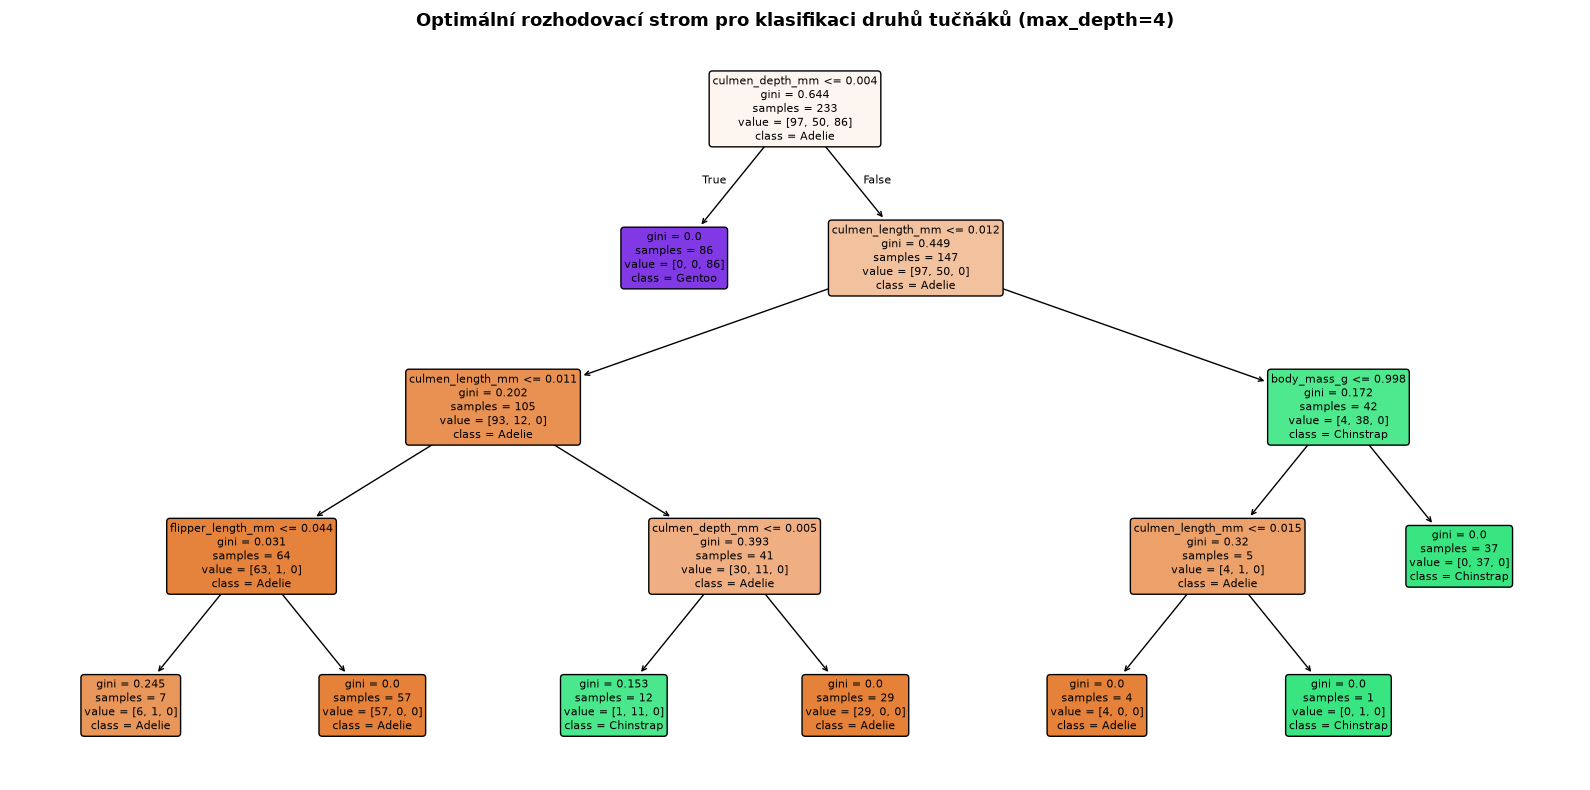

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    opt_model,
    feature_names=feature_cols,
    class_names=classes,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.title("Optimální rozhodovací strom pro klasifikaci druhů tučňáků (max_depth=4)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
